# Train Small House Set LoRA

Self-contained LoRA training for `stable-diffusion-v1-5/stable-diffusion-inpainting`.

This notebook reads image/mask pairs from `datasets/small_house_set` and saves adapter weights to `notebooks/outputs/lora_small_house_set_sd15_inpaint`.


In [16]:
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "backend").exists() and (candidate / "frontend").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Run this notebook from the repo or notebooks directory.")


REPO_ROOT = find_repo_root()
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
DATASET_DIR = REPO_ROOT / "datasets" / "small_house_set"
VALIDATION_IMAGE_PATH = REPO_ROOT / "test_images" / "satelite-image.png"
VALIDATION_MASK_PATH = REPO_ROOT / "test_images" / "satelite-mask.png"
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "lora_small_house_set_sd15_inpaint"

INSTANCE_PROMPT = "small house"
VALIDATION_PROMPT = "small house"
NEGATIVE_PROMPT = "trees, vegetation, forest, bushes, blurry, distorted, repeated roofs, warped perspective, low quality"

RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
# This tiny set needs more repetitions before the adapter visibly moves the model.
# Use a lower LR for the longer run so it can keep improving without jumping around as much.
LEARNING_RATE = 5e-5
MAX_TRAIN_STEPS = 3000
CHECKPOINTING_STEPS = 500
RANK = 16
LORA_ALPHA = 16
MASK_LOSS_WEIGHT = 1.0
BACKGROUND_LOSS_WEIGHT = 0.0
VALIDATION_LORA_SCALE = 1.0
VALIDATION_STRENGTH = 0.9
VALIDATION_GUIDANCE_SCALE = 5.5
SEED = 42
LOCAL_FILES_ONLY = False
MIXED_PRECISION = "fp16"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", REPO_ROOT)
print("dataset:", DATASET_DIR)
print("validation image:", VALIDATION_IMAGE_PATH)
print("validation mask:", VALIDATION_MASK_PATH)
print("training prompt:", INSTANCE_PROMPT)
print("validation prompt:", VALIDATION_PROMPT)
print("validation LoRA scale:", VALIDATION_LORA_SCALE)
print("masked/background loss weights:", MASK_LOSS_WEIGHT, BACKGROUND_LOSS_WEIGHT)
print("output:", OUTPUT_DIR)


repo root: C:\Users\neman\Documents\UVPython\inpainting
dataset: C:\Users\neman\Documents\UVPython\inpainting\datasets\small_house_set
validation image: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-image.png
validation mask: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-mask.png
training prompt: small house
validation prompt: small house
validation LoRA scale: 1.0
masked/background loss weights: 1.0 0.0
output: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_small_house_set_sd15_inpaint


In [17]:
import json
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration, set_seed
from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionInpaintPipeline, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params
from diffusers.utils import convert_state_dict_to_diffusers
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image
from skimage.measure import label, regionprops
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from transformers import CLIPTextModel, CLIPTokenizer


IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff"}


@dataclass
class Record:
    image_path: Path
    mask_path: Path
    prompt: str


def load_records(dataset_dir: Path, default_prompt: str) -> list[Record]:
    metadata_path = dataset_dir / "metadata.jsonl"
    records = []

    if metadata_path.exists():
        for line in metadata_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            row = json.loads(line)
            image_value = row.get("image")
            if image_value is None:
                continue
            image_path = Path(image_value)
            if not image_path.is_absolute():
                image_path = dataset_dir / image_path
            mask_value = row.get("mask")
            if mask_value is None:
                mask_path = dataset_dir / "masks" / f"{image_path.stem}_mask.png"
            else:
                mask_path = Path(mask_value)
                if not mask_path.is_absolute():
                    mask_path = dataset_dir / mask_path
            records.append(Record(image_path, mask_path, training_prompt(row.get("prompt"), default_prompt)))
    else:
        search_dirs = [dataset_dir / "images", dataset_dir]
        seen = set()
        for search_dir in search_dirs:
            if not search_dir.exists():
                continue
            for image_path in sorted(search_dir.iterdir()):
                if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS and image_path not in seen:
                    mask_path = dataset_dir / "masks" / f"{image_path.stem}_mask.png"
                    records.append(Record(image_path, mask_path, default_prompt))
                    seen.add(image_path)

    records = [record for record in records if record.image_path.exists() and record.mask_path.exists()]
    if not records:
        raise ValueError(f"No image/mask training pairs found in {dataset_dir}")
    return records


def training_prompt(value: str | None, default_prompt: str) -> str:
    prompt = (value or default_prompt).strip()
    for prefix in ("satellite view of ", "satellite view ", "satelite view of ", "satelite view "):
        if prompt.lower().startswith(prefix):
            prompt = prompt[len(prefix):].strip()
            break
    return prompt or default_prompt


def load_validation_pair(image_path: Path, mask_path: Path) -> tuple[Image.Image, Image.Image]:
    if not image_path.exists() or not mask_path.exists():
        raise FileNotFoundError(
            f"Missing validation image/mask pair:\n  image: {image_path}\n  mask: {mask_path}"
        )
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    if mask.size != image.size:
        mask = mask.resize(image.size, Image.Resampling.NEAREST)
    mask = mask.point(lambda value: 255 if value > 127 else 0)
    return image, mask


class InpaintDataset(Dataset):
    def __init__(self, dataset_dir: Path, tokenizer, resolution: int, prompt: str):
        self.records = load_records(dataset_dir, prompt)
        self.tokenizer = tokenizer
        self.resolution = resolution
        self.image_to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.records)

    def preprocess(self, image: Image.Image, mask: Image.Image):
        if mask.size != image.size:
            mask = mask.resize(image.size, Image.Resampling.NEAREST)

        mask_array = np.asarray(mask.convert("L")) > 127
        labeled = label(mask_array, connectivity=2)
        components = [region for region in regionprops(labeled) if region.area >= 32]

        if components:
            region = random.choice(components)
            min_row, min_col, max_row, max_col = region.bbox
            component_mask = (labeled == region.label).astype(np.uint8) * 255
            mask = Image.fromarray(component_mask).convert("L")

            box_width = max_col - min_col
            box_height = max_row - min_row
            crop_size = int(max(box_width, box_height) * 5)
            crop_size = max(192, min(crop_size, min(image.size)))
            center_x = (min_col + max_col) // 2
            center_y = (min_row + max_row) // 2

            jitter = max(0, crop_size // 8)
            center_x += random.randint(-jitter, jitter) if jitter else 0
            center_y += random.randint(-jitter, jitter) if jitter else 0

            left = max(0, min(center_x - crop_size // 2, image.width - crop_size))
            top = max(0, min(center_y - crop_size // 2, image.height - crop_size))
            image = TF.crop(image, top, left, crop_size, crop_size)
            mask = TF.crop(mask, top, left, crop_size, crop_size)
        else:
            mask = mask.point(lambda value: 255 if value > 127 else 0)

        image = TF.resize(image, (self.resolution, self.resolution), interpolation=transforms.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (self.resolution, self.resolution), interpolation=transforms.InterpolationMode.NEAREST)
        mask = mask.point(lambda value: 255 if value > 127 else 0)
        return image, mask

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record.image_path).convert("RGB")
        mask = Image.open(record.mask_path).convert("L")
        image, mask = self.preprocess(image, mask)

        image_tensor = self.image_to_tensor(image)
        mask_tensor = (transforms.ToTensor()(mask) > 0.5).float()
        masked_image = image_tensor * (mask_tensor < 0.5)
        input_ids = self.tokenizer(record.prompt, padding="do_not_pad", truncation=True, max_length=self.tokenizer.model_max_length).input_ids
        return {"pixel_values": image_tensor, "mask": mask_tensor, "masked_image": masked_image, "input_ids": input_ids}


def collate_fn(examples, tokenizer):
    return {
        "pixel_values": torch.stack([example["pixel_values"] for example in examples]).contiguous().float(),
        "masks": torch.stack([example["mask"] for example in examples]).contiguous().float(),
        "masked_images": torch.stack([example["masked_image"] for example in examples]).contiguous().float(),
        "input_ids": tokenizer.pad({"input_ids": [example["input_ids"] for example in examples]}, padding=True, return_tensors="pt").input_ids,
    }


def save_lora(unet, output_dir: Path):
    state_dict = get_peft_model_state_dict(unet)
    state_dict = convert_state_dict_to_diffusers(state_dict)
    StableDiffusionInpaintPipeline.save_lora_weights(str(output_dir), unet_lora_layers=state_dict, safe_serialization=True)


def summarize_training_masks(records: list[Record]) -> None:
    """Print mask coverage so white/black convention problems show up before training."""
    coverages = []
    component_counts = []
    for record in records:
        mask = Image.open(record.mask_path).convert("L")
        mask_array = np.asarray(mask) > 127
        coverages.append(float(mask_array.mean()))
        component_counts.append(int(label(mask_array, connectivity=2).max()))

    print("mask coverage min/mean/max:", min(coverages), float(np.mean(coverages)), max(coverages))
    print("mask components min/mean/max:", min(component_counts), float(np.mean(component_counts)), max(component_counts))
    if max(coverages) == 0.0:
        raise ValueError("All training masks are empty. White pixels must mark repaint regions.")
    if min(coverages) >= 0.99:
        raise ValueError("Training masks are almost fully white. Black pixels must mark preserved regions.")


records = load_records(DATASET_DIR, INSTANCE_PROMPT)
summarize_training_masks(records)
sample_image, sample_mask = load_validation_pair(VALIDATION_IMAGE_PATH, VALIDATION_MASK_PATH)
print("records:", len(records))
print("first training image:", records[0].image_path)
print("first training mask:", records[0].mask_path)
print("validation image:", VALIDATION_IMAGE_PATH)
print("validation mask:", VALIDATION_MASK_PATH)


mask coverage min/mean/max: 0.20092514162018066 0.2287723940487728 0.2701943891190932
mask components min/mean/max: 42 59.75 83
records: 4
first training image: C:\Users\neman\Documents\UVPython\inpainting\datasets\small_house_set\house1.jpg
first training mask: C:\Users\neman\Documents\UVPython\inpainting\datasets\small_house_set\masks\house1_mask.png
validation image: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-image.png
validation mask: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-mask.png


mask coverage: 0.04028017555428772


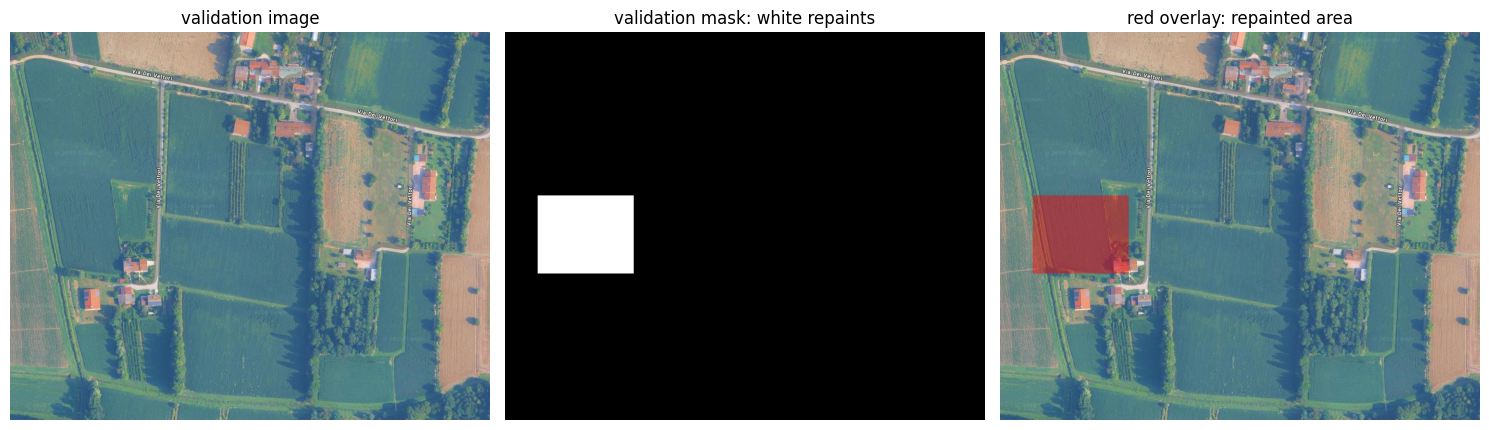

In [18]:
mask_array = np.asarray(sample_mask)
mask_coverage = float((mask_array > 0).mean())
print("mask coverage:", mask_coverage)

overlay = np.asarray(sample_image.convert("RGB")).copy()
overlay_mask = mask_array > 0
overlay[overlay_mask] = (0.55 * overlay[overlay_mask] + 0.45 * np.array([255, 0, 0])).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_image)
axes[0].set_title("validation image")
axes[0].axis("off")
axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title("validation mask: white repaints")
axes[1].axis("off")
axes[2].imshow(overlay)
axes[2].set_title("red overlay: repainted area")
axes[2].axis("off")
plt.tight_layout()


In [19]:
set_seed(SEED)

accelerator = Accelerator(
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    mixed_precision=MIXED_PRECISION,
    project_config=ProjectConfiguration(project_dir=str(OUTPUT_DIR), logging_dir=str(OUTPUT_DIR / "logs")),
)

load_kwargs = {"local_files_only": LOCAL_FILES_ONLY}
model_load_kwargs = {**load_kwargs, "use_safetensors": False}
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", **load_kwargs)
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", **model_load_kwargs)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", **model_load_kwargs)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", **model_load_kwargs)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler", **load_kwargs)

if int(unet.config.in_channels) != 9:
    raise RuntimeError(f"Expected inpainting UNet with 9 channels, got {unet.config.in_channels}")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)
unet.add_adapter(LoraConfig(r=RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=["to_q", "to_k", "to_v", "to_out.0"]))
unet.enable_gradient_checkpointing()
cast_training_params(unet, dtype=torch.float32)

weight_dtype = torch.float16 if MIXED_PRECISION == "fp16" else torch.float32
vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

dataset = InpaintDataset(DATASET_DIR, tokenizer, RESOLUTION, INSTANCE_PROMPT)
dataloader = DataLoader(dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=lambda examples: collate_fn(examples, tokenizer))

trainable_params = [parameter for parameter in unet.parameters() if parameter.requires_grad]
print("trainable params:", sum(parameter.numel() for parameter in trainable_params))
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8)
lr_scheduler = get_scheduler("constant", optimizer=optimizer, num_warmup_steps=0, num_training_steps=MAX_TRAIN_STEPS)

unet, optimizer, dataloader, lr_scheduler = accelerator.prepare(unet, optimizer, dataloader, lr_scheduler)

global_step = 0
num_epochs = math.ceil(MAX_TRAIN_STEPS / max(1, math.ceil(len(dataloader) / GRADIENT_ACCUMULATION_STEPS)))
for epoch in range(num_epochs):
    unet.train()
    running_loss = 0.0
    for step, batch in enumerate(dataloader):
        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(dtype=weight_dtype)
            masks = batch["masks"].to(dtype=weight_dtype)
            masked_images = batch["masked_images"].to(dtype=weight_dtype)
            input_ids = batch["input_ids"].to(accelerator.device)

            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
            masked_latents = vae.encode(masked_images).latent_dist.sample() * vae.config.scaling_factor
            mask_latents = F.interpolate(masks, size=latents.shape[-2:])
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids, return_dict=False)[0]
            model_input = torch.cat([noisy_latents, mask_latents, masked_latents], dim=1)
            model_pred = unet(model_input, timesteps, encoder_hidden_states=encoder_hidden_states, return_dict=False)[0]
            squared_error = (model_pred.float() - noise.float()).pow(2)
            loss_weights = torch.where(
                mask_latents > 0.5,
                torch.full_like(mask_latents, MASK_LOSS_WEIGHT),
                torch.full_like(mask_latents, BACKGROUND_LOSS_WEIGHT),
            )
            loss = (squared_error * loss_weights).sum() / (loss_weights.sum() * squared_error.shape[1]).clamp(min=1.0)

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            running_loss += loss.detach().item()

        if accelerator.sync_gradients:
            global_step += 1
            if global_step % 10 == 0:
                accelerator.print(f"step {global_step}/{MAX_TRAIN_STEPS} loss={running_loss / max(1, step + 1):.4f}")
            if global_step % CHECKPOINTING_STEPS == 0 and accelerator.is_main_process:
                save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR / f"checkpoint-{global_step}")
            if global_step >= MAX_TRAIN_STEPS:
                break
    if global_step >= MAX_TRAIN_STEPS:
        break

accelerator.wait_for_everyone()
if accelerator.is_main_process:
    save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR)
    (OUTPUT_DIR / "training_args.json").write_text(json.dumps({
        "model_id": MODEL_ID,
        "dataset_dir": str(DATASET_DIR),
        "training_prompt": INSTANCE_PROMPT,
        "validation_prompt": VALIDATION_PROMPT,
        "resolution": RESOLUTION,
        "max_train_steps": MAX_TRAIN_STEPS,
        "learning_rate": LEARNING_RATE,
        "rank": RANK,
        "lora_alpha": LORA_ALPHA,
        "mask_loss_weight": MASK_LOSS_WEIGHT,
        "background_loss_weight": BACKGROUND_LOSS_WEIGHT,
        "validation_lora_scale": VALIDATION_LORA_SCALE,
        "validation_strength": VALIDATION_STRENGTH,
        "validation_guidance_scale": VALIDATION_GUIDANCE_SCALE,
        "seed": SEED,
    }, indent=2), encoding="utf-8")
print("saved:", OUTPUT_DIR / "pytorch_lora_weights.safetensors")


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 3188736
step 10/3000 loss=0.1149
step 20/3000 loss=0.1908
step 30/3000 loss=0.2117
step 40/3000 loss=0.0745
step 50/3000 loss=0.0283
step 60/3000 loss=0.0328
step 70/3000 loss=0.1261
step 80/3000 loss=0.1013
step 90/3000 loss=0.1106
step 100/3000 loss=0.1111
step 110/3000 loss=0.0157
step 120/3000 loss=0.2406
step 130/3000 loss=0.2803
step 140/3000 loss=0.1198
step 150/3000 loss=0.2323
step 160/3000 loss=0.0938
step 170/3000 loss=0.1225
step 180/3000 loss=0.2890
step 190/3000 loss=0.1591
step 200/3000 loss=0.1246
step 210/3000 loss=0.0460
step 220/3000 loss=0.1558
step 230/3000 loss=0.1708
step 240/3000 loss=0.2672
step 250/3000 loss=0.0254
step 260/3000 loss=0.2741
step 270/3000 loss=0.0305
step 280/3000 loss=0.1273
step 290/3000 loss=0.1662
step 300/3000 loss=0.1552
step 310/3000 loss=0.1892
step 320/3000 loss=0.3056
step 330/3000 loss=0.1394
step 340/3000 loss=0.1405
step 350/3000 loss=0.2302
step 360/3000 loss=0.2263
step 370/3000 loss=0.2069
step 380/3000 loss=0.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

base vs LoRA mean abs diff: 1.226561188697815


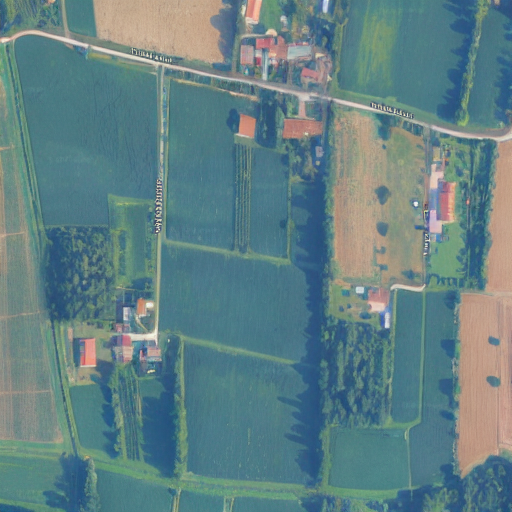

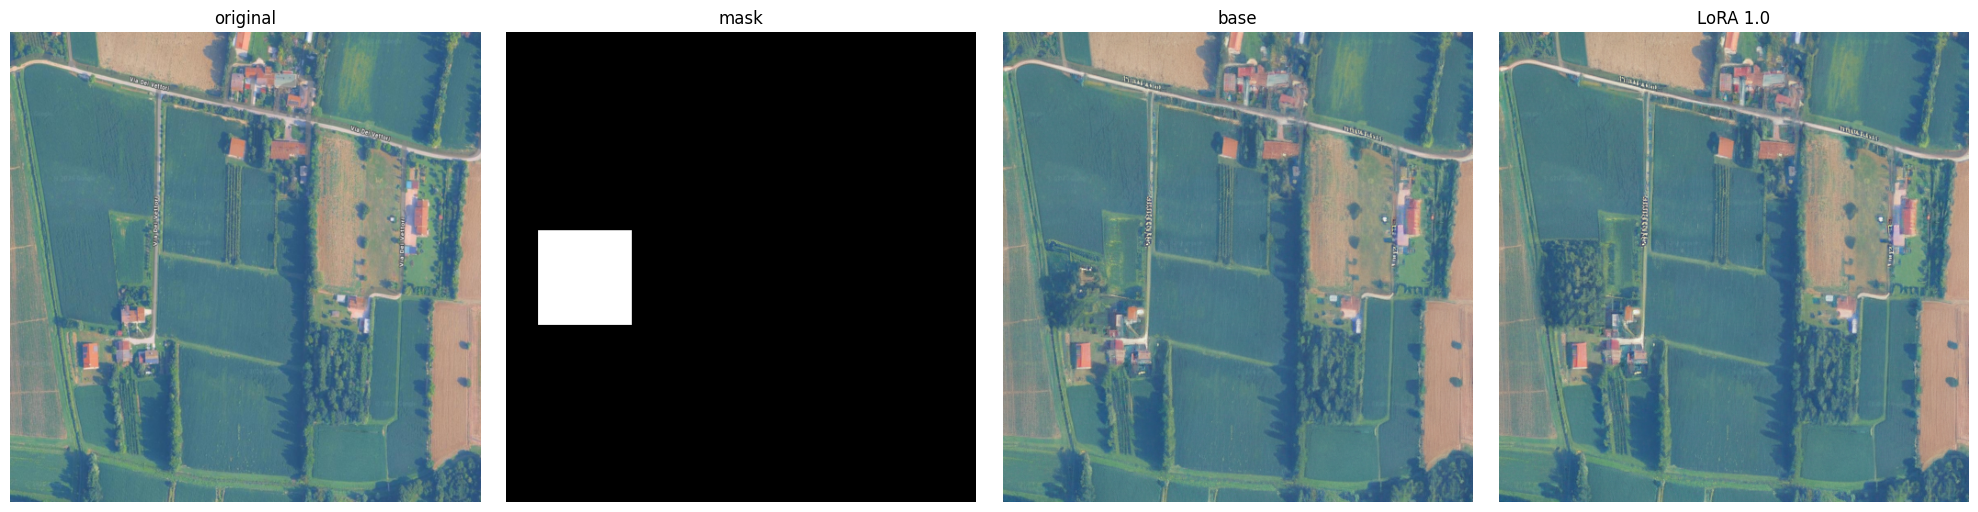

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
adapter_name = "small_houses"
pipe = StableDiffusionInpaintPipeline.from_pretrained(MODEL_ID, torch_dtype=dtype, safety_checker=None, local_files_only=LOCAL_FILES_ONLY, use_safetensors=False).to(device)
pipe.load_lora_weights(str(OUTPUT_DIR), adapter_name=adapter_name)
pipe.enable_lora()
pipe.set_progress_bar_config(disable=False)

test_image = sample_image.resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)
test_mask = sample_mask.resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)

def run_validation(adapter_weight: float):
    # Reuse the same seed so the only intended difference is the LoRA adapter weight.
    pipe.enable_lora()
    pipe.set_adapters([adapter_name], adapter_weights=[adapter_weight])
    generator = torch.Generator(device=device).manual_seed(7)
    return pipe(
        prompt=VALIDATION_PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        image=test_image,
        mask_image=test_mask,
        height=RESOLUTION,
        width=RESOLUTION,
        strength=VALIDATION_STRENGTH,
        num_inference_steps=40,
        guidance_scale=VALIDATION_GUIDANCE_SCALE,
        generator=generator,
    ).images[0]

validation_base = run_validation(0.0)
validation = run_validation(VALIDATION_LORA_SCALE)
validation_base.save(OUTPUT_DIR / "validation_base.png")
validation.save(OUTPUT_DIR / "validation_lora.png")

diff = float(torch.as_tensor(np.asarray(validation_base, dtype=np.int16) - np.asarray(validation, dtype=np.int16)).abs().float().mean())
print("base vs LoRA mean abs diff:", diff)
if diff == 0.0:
    raise RuntimeError("LoRA validation is identical to base. Check that training finished and the adapter weights changed.")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for axis, title, item, cmap in [
    (axes[0], "original", test_image, None),
    (axes[1], "mask", test_mask, "gray"),
    (axes[2], "base", validation_base, None),
    (axes[3], f"LoRA {VALIDATION_LORA_SCALE}", validation, None),
]:
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
validation
